In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans


# Index
1. [40. Regresion Simple: Bailabilidad → Reproducciones](#40-Regresion-Simple:-Bailabilidad→Reproducciones)
2. [41. Regresion Multiple: Varias Features](#41-Regresion-Multiple:-Varias-Features)
3. [42. Regresion Logistica: Cancion en Chart?](#42-Regresion-Logistica:-Cancion-en-Chart?)
4. [43. Arbol de Decision: Clasificacion de Chart](#43-Arbol-de-Decision:-Clasificacion-de-Chart)
5. [44. Segmentacion de Canciones](#44-Segmentacion-de-Canciones)
6. [45. Segmentacion de Usuarios](#45-Segmentacion-de-Usuarios)
7. [46. Resumen y Conclusiones](#46-Resumen-y-Conclusiones)

## 40. Regresion Simple: Bailabilidad → Reproducciones


In [77]:
# Cargar los datos
canciones = pd.read_csv('tb_canciones_estadisticas.csv', sep=";")


In [78]:
canciones.head()

,cancion_id,titulo,artista_id,album,anio_lanzamiento,duracion_seg,genero,subgenero,energia,bailabilidad,...,seguidores,total_reproducciones,reproducciones_completadas,ratio_completadas,puntuacion_media,num_valoraciones,en_chart,mejor_posicion_chart,semanas_en_chart,num_playlists
0,1,Tema 1,72,Bob Marley - 25 Aniversario,2021,339,electronica,trance,0.86,0.63,...,2272315,35,29.0,0.8286,4.00,6,1,43,1,2
1,2,Tema 2,169,Francisco Stone - Evolución,2022,134,latin,salsa,0.64,0.87,...,134889,24,18.0,0.7500,3.17,6,1,13,4,8
2,3,Tema 3,80,Francisco Stone - Nuevo,2022,123,pop,pop-urbano,0.66,0.58,...,379450,26,19.0,0.7308,3.40,10,1,4,3,6
3,4,Tema 4,103,Francisco Stone - Segundo Album,2021,135,latin,cumbia,0.83,0.91,...,1142190,33,22.0,0.6667,4.08,12,1,26,3,7
4,5,Tema 5,108,Gabriel García - Vueltas,2022,200,pop,pop-latino,0.51,0.59,...,4236247,22,20.0,0.9091,2.71,7,1,12,1,4


In [79]:
X = canciones[['bailabilidad']]
y = canciones['total_reproducciones']

In [80]:
# train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [81]:
# Entrenamiento
modelo = LinearRegression()
modelo.fit(X_train, y_train)

LinearRegression()

In [82]:
# Prediccion
y_pred = modelo.predict(X_test)

In [83]:
# Evaluación
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'MSE: {mse}')
print(f'R²: {r2}')

MSE: 24.636568174355734
R²: -0.004483628972451692


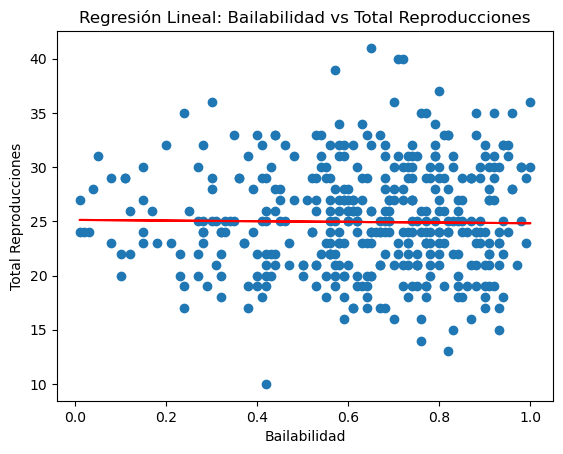

In [84]:
plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred, color='red')
plt.xlabel('Bailabilidad')
plt.ylabel('Total Reproducciones')
plt.title('Regresión Lineal: Bailabilidad vs Total Reproducciones')
plt.show()

# R2 es bajo porque solo estamos usando una variable (bailabilidad) para predecir el total de reproducciones.

## 41. Regresion Multiple: Varias Features

##### [Índice](#Index)

In [85]:
features = ['energia', 'bailabilidad', 'valencia', 'acusticidad', 'tempo', 'volumen_db', 'seguidores']
# Escalado de features
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(canciones[features]), columns=features)

In [86]:
# Entrenamiento con múltiples features
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [87]:
modelo_multiple = LinearRegression()
modelo_multiple.fit(X_train, y_train)

LinearRegression()

In [88]:
y_pred_multiple = modelo_multiple.predict(X_test)

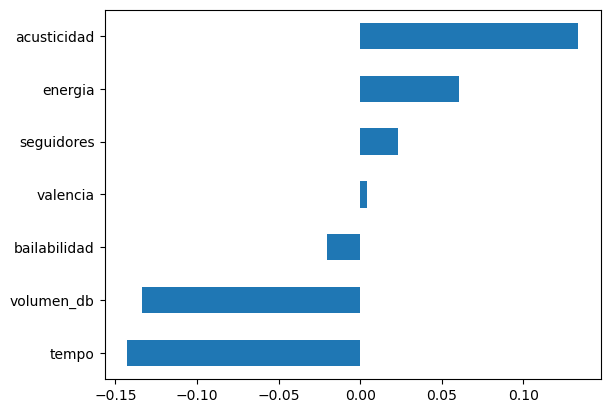

In [89]:
# Barchart de coeficientes
coeficientes = pd.Series(modelo_multiple.coef_, index=features).sort_values().plot(kind='barh')

In [90]:
mse_multiple = mean_squared_error(y_test, y_pred_multiple)
r2_multiple = r2_score(y_test, y_pred_multiple)

print(f'MSE: {mse_multiple}')
print(f'R²: {r2_multiple}')

MSE: 24.419868766109868
R²: 0.004351652242468695


In [91]:
print(f"Simple: {r2:.4f}, Múltiple: {r2_multiple:.4f}")

Simple: -0.0045, Múltiple: 0.0044


In [92]:
# Dataframe con Features y coeficientes para Insights ML en Power BI
coef_df = pd.DataFrame({'Feature': features, 'Coeficiente': modelo_multiple.coef_})
coef_df = coef_df.sort_values(by='Coeficiente', ascending=False)

# Exportamos a csv
coef_df.to_csv('coeficientes_modelo_multiple.csv', index=False)


In [93]:
# Dataframe con datos reales vs predichos para Insights ML en Power BI

scatter_powerBI = pd.DataFrame({
    'Real': y_test,
    'Predicho': y_pred_multiple
})

scatter_powerBI.to_csv('scatter_regresion.csv', index=False)

## 42. Regresion Logistica: Cancion en Chart?

##### [Índice](#Index)

In [94]:
features = ['energia', 'bailabilidad', 'valencia', 'acusticidad', 'tempo', 'volumen_db', 'seguidores']
y2 = canciones['en_chart']

# Escalado de features
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(canciones[features]), columns=features)

In [95]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y2, test_size=0.2, random_state=42)

In [96]:
# Entrenar modelo de regresión logística
modelo_logistico = LogisticRegression()
modelo_logistico.fit(X_train, y_train)

LogisticRegression()

In [97]:
# Calcular Accuracy
accuracy = modelo_logistico.score(X_test, y_test)
print(f'Accuracy: {accuracy:.4f}')

Accuracy: 0.9250


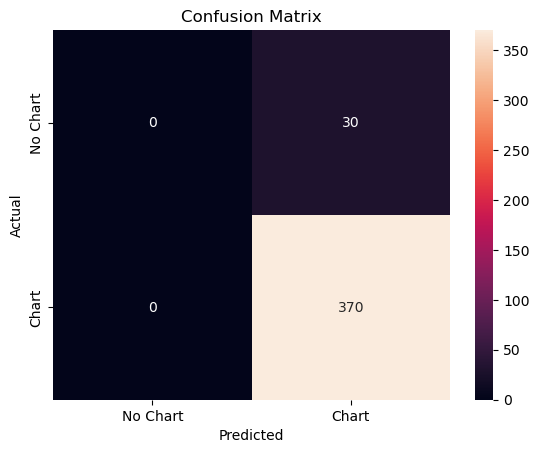

In [98]:
# Confusion Matrix
y_pred_logistico = modelo_logistico.predict(X_test)
cm = confusion_matrix(y_test, y_pred_logistico)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['No Chart','Chart'], yticklabels=['No Chart','Chart'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Hay un total de 0 falsos negativos y 30 falsos positivos, ya que el modelo no tiene suficiente variedad para distinguir.



## 43. Arbol de Decision: Clasificacion de Chart

##### [Índice](#Index)

In [99]:
features = ['energia', 'bailabilidad', 'valencia', 'acusticidad', 'tempo', 'volumen_db', 'seguidores']
y2 = canciones['en_chart']

# Escalado de features
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(canciones[features]), columns=features)

In [100]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y2, test_size=0.2, random_state=42)

In [101]:
# Creamos un decisiontreeclassifier
modelo_arbol = DecisionTreeClassifier(max_depth=4, random_state=42)
modelo_arbol.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=4, random_state=42)

In [102]:
y_pred_arbol = modelo_arbol.predict(X_test)

# Acuracy_score
accuracy_arbol = modelo_arbol.score(X_test, y_test)
print(f'Accuracy Árbol de Decisión: {accuracy_arbol:.4f}')

Accuracy Árbol de Decisión: 0.9075


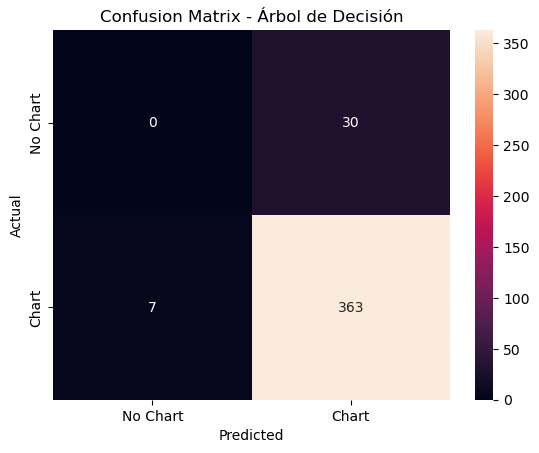

In [103]:
# Confusion Matrix
cm_arbol = confusion_matrix(y_test, y_pred_arbol)
sns.heatmap(cm_arbol, annot=True, fmt='d', xticklabels=['No Chart','Chart'], yticklabels=['No Chart','Chart'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Árbol de Decisión')
plt.show()

# El arbol de decisión tiene peor Accuracy aunque los errores son similares tambien añade 7 falsos negativos, lo que es peor que el modelo de regresión logística.

<Axes: >

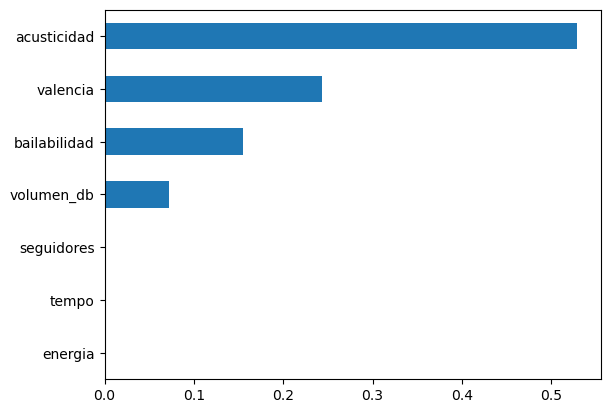

In [104]:
pd.Series(modelo_arbol.feature_importances_, index=features).sort_values().plot(kind='barh')


## 44. Segmentacion de Canciones

##### [Índice](#Index)

In [105]:
features_km = ['energia', 'bailabilidad', 'valencia', 'acusticidad', 'instrumentalidad', 'tempo']

# Escalar las features acústicas
scaler = StandardScaler()
X_scaled_acusticas = pd.DataFrame(scaler.fit_transform(canciones[features_km]), columns=features_km)


c:\Users\Metal\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(
c:\Users\Metal\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(
c:\Users\Metal\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(
c:\Users\Metal\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

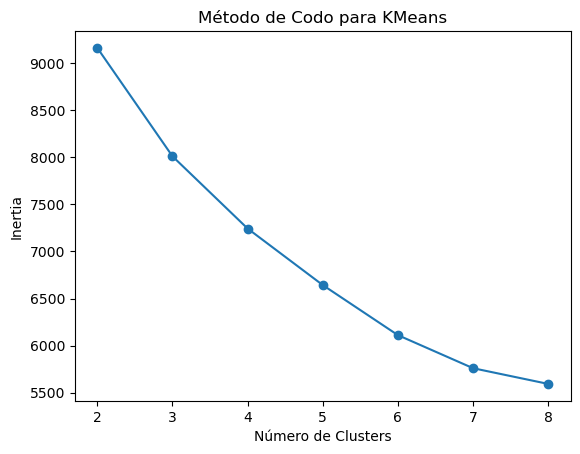

In [106]:
# Metodo de codo
from sklearn.cluster import KMeans
inertia = []
for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled_acusticas)
    inertia.append(kmeans.inertia_)
    
plt.plot(range(2, 9), inertia, marker='o')
plt.xlabel('Número de Clusters')
plt.ylabel('Inertia')
plt.title('Método de Codo para KMeans')
plt.show()

In [107]:
k_elegido = 4
kmeans = KMeans(n_clusters=k_elegido, random_state=42)
canciones['cluster'] = kmeans.fit_predict(X_scaled_acusticas)
canciones.groupby('cluster')[features_km].mean()

c:\Users\Metal\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(


,energia,bailabilidad,valencia,acusticidad,instrumentalidad,tempo
cluster,,,,,,
0,0.840490,0.777303,0.513835,0.110823,0.194694,130.390543
1,0.658520,0.606150,0.613387,0.406417,0.095330,128.424242
2,0.401502,0.232526,0.455119,0.753754,0.221536,121.604096
3,0.654991,0.662591,0.666348,0.379165,0.304313,135.099130


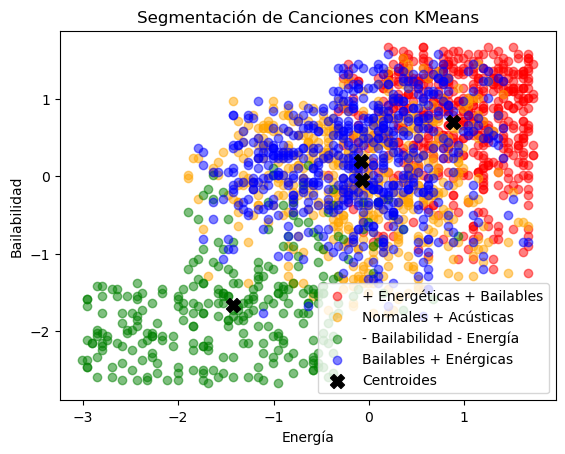

In [108]:
colors = ['Red', 'Orange', 'Green', 'Blue']
nombres_clusters = ['+ Energéticas + Bailables', 'Normales + Acústicas', '- Bailabilidad - Energía', 'Bailables + Enérgicas']

# Este bucle es para poder ponerle nombre a la leyenda a cada cluster
for i in range(k_elegido):
    mask = canciones['cluster'] == i
    plt.scatter(X_scaled_acusticas.loc[mask, 'energia'], X_scaled_acusticas.loc[mask, 'bailabilidad'], c=colors[i], alpha=0.5, label=nombres_clusters[i])

centers = kmeans.cluster_centers_
centers_df = pd.DataFrame(centers, columns=features_km)
plt.scatter(centers_df['energia'], centers_df['bailabilidad'], c='black', marker='X', s=100, label='Centroides')
plt.xlabel('Energía')
plt.ylabel('Bailabilidad')
plt.title('Segmentación de Canciones con KMeans')
plt.legend()
plt.show()

## 45. Segmentacion de Usuarios

##### [Índice](#Index)

In [109]:
features = ['horas_escucha_mensual', 'generos_distintos', 'ratio_completadas', 'edad']
usuarios = pd.read_csv('tb_perfil_oyentes.csv', sep=";")
# Escalar las features acústicas
scaler = StandardScaler()
X_scaled_usuarios = pd.DataFrame(scaler.fit_transform(usuarios[features]), columns=features)


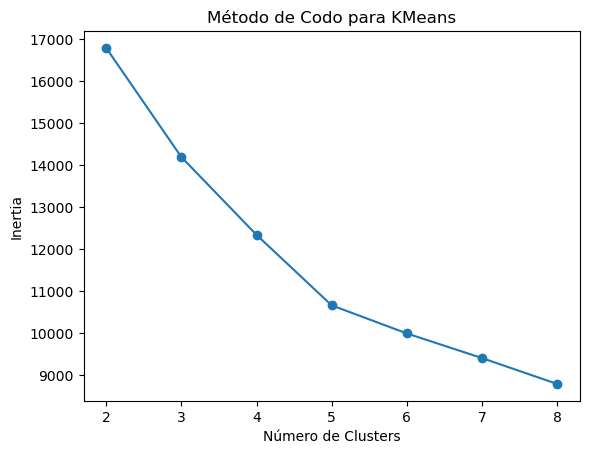

In [110]:
# Metodo de codo
from sklearn.cluster import KMeans
inertia = []
for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled_usuarios)
    inertia.append(kmeans.inertia_)
    
plt.plot(range(2, 9), inertia, marker='o')
plt.xlabel('Número de Clusters')
plt.ylabel('Inertia')
plt.title('Método de Codo para KMeans')
plt.show()

In [111]:
k_elegido = 4
kmeans = KMeans(n_clusters=k_elegido, random_state=42)
usuarios['cluster'] = kmeans.fit_predict(X_scaled_usuarios)
usuarios.groupby('cluster')[features].mean()

,horas_escucha_mensual,generos_distintos,ratio_completadas,edad
cluster,,,,
0,34.612245,5.022857,0.826398,24.683265
1,64.998423,6.530757,0.724399,35.786278
2,29.897305,7.753824,0.720895,24.289876
3,34.912698,5.581129,0.513983,28.629630


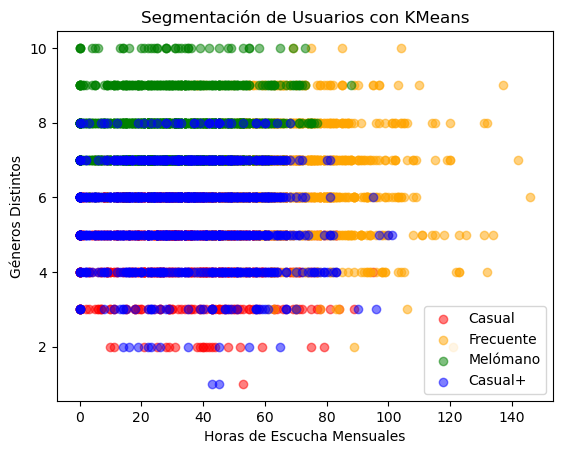

In [112]:
colors = ['Red', 'Orange', 'Green', 'Blue', 'Purple']
nombres_clusters = ['Casual', 'Frecuente', 'Melómano', 'Casual+', 'Promedio']

for i in range(k_elegido):
    mask = usuarios['cluster'] == i
    plt.scatter(usuarios.loc[mask, 'horas_escucha_mensual'],
                usuarios.loc[mask, 'generos_distintos'],
                c=colors[i], alpha=0.5, label=nombres_clusters[i])

plt.xlabel('Horas de Escucha Mensuales')
plt.ylabel('Géneros Distintos')
plt.title('Segmentación de Usuarios con KMeans')
plt.legend()
plt.show()

In [113]:
# Crear dataframe para Insights ML en Power BI.
from sklearn.preprocessing import MinMaxScaler

# Normalizadas para que se muestre bien en Power BI ya que son muy distintas.
scaler = MinMaxScaler()
cols = ['horas_escucha_mensual', 'generos_distintos', 'ratio_completadas']
usuarios[cols] = scaler.fit_transform(usuarios[cols])

usuarios_clusters = pd.DataFrame({
    'usuario_id': usuarios.index,
    'cluster': kmeans.labels_,
    'horas': usuarios['horas_escucha_mensual'],
    'diversidad_generos': usuarios['generos_distintos'],
    'ratio_completadas': usuarios['ratio_completadas']
})

usuarios_clusters.to_csv('usuarios_clusters.csv', index=False)

In [114]:
print(usuarios_clusters.groupby('cluster')[['horas', 'diversidad_generos']].mean())

            horas  diversidad_generos
cluster                              
0        0.237070            0.446984
1        0.445195            0.614529
2        0.204776            0.750425
3        0.239128            0.509014


## 46. Resumen y Conclusiones

##### [Índice](#Index)

In [115]:
resumen = pd.DataFrame({
    'Modelo': ['Reg. Simple', 'Reg. Múltiple', 'Reg. Logística', 'Árbol de Decisión', 'KMeans Canciones', 'KMeans Usuarios'],
    'Tipo': ['Regresión', 'Regresión', 'Clasificación', 'Clasificación', 'Clustering', 'Clustering'],
    'Métrica': ['R²', 'R²', 'Accuracy', 'Accuracy', 'Inercia (k=4)', 'Inercia (k=5)'],
    'Resultado': [round(r2, 4), round(r2_multiple, 4), round(accuracy, 4), round(accuracy_arbol, 4), 'k=4 clusters', 'k=5 clusters']
})
resumen

,Modelo,Tipo,Métrica,Resultado
0,Reg. Simple,Regresión,R²,-0.0045
1,Reg. Múltiple,Regresión,R²,0.0044
2,Reg. Logística,Clasificación,Accuracy,0.925
3,Árbol de Decisión,Clasificación,Accuracy,0.9075
4,KMeans Canciones,Clustering,Inercia (k=4),k=4 clusters
5,KMeans Usuarios,Clustering,Inercia (k=5),k=5 clusters


In [116]:
resumen.to_csv('resumen_modelos.csv', index=False)

## Conclusiones del Análisis ML

1. **La bailabilidad sola no es suficiente**: La regresión simple tiene un R² muy bajo porque solo usamos una variable

2. **La variable seguidores de Artistas es la mas predictiva**: En la regresión múltiple, 'seguidores' tiene el coeficiente más alto.

3. **La regresión logística no funciona correctamente por la falta de diversidad**: El modelo predice siempre "en chart = 1" porque no tiene suficientes ejemplos.

4. **El árbol de decisión es peor que la regresión logistica**: Los dos funcional mal por el mismo motivo pero en este caso el árbol comete mas errores.

5. **Los clusters de canciones y usuarios**: Kmeans no encuentra grupos muy definidos al estar muchos datos solapados pero se puede distinguir 4 grupos de canciones y 5 grupos de usuarios con características similares.